In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
len(words)

32033

In [29]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i:s for s,i in stoi.items() }
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [6]:
block_size = 3
X, Y = [], []

for w in words:
        # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [8]:
C = torch.randn((27, 2))

In [9]:
emb = C[X]
emb

tensor([[[ 1.7515, -0.9615],
         [ 1.7515, -0.9615],
         [ 1.7515, -0.9615]],

        [[ 1.7515, -0.9615],
         [ 1.7515, -0.9615],
         [ 0.1880, -0.1414]],

        [[ 1.7515, -0.9615],
         [ 0.1880, -0.1414],
         [ 1.0275, -0.2960]],

        ...,

        [[ 0.0396,  0.3358],
         [ 0.0396,  0.3358],
         [-0.7291,  0.5143]],

        [[ 0.0396,  0.3358],
         [-0.7291,  0.5143],
         [ 0.0396,  0.3358]],

        [[-0.7291,  0.5143],
         [ 0.0396,  0.3358],
         [-0.4564,  1.4492]]])

In [10]:
W1 = torch.randn((6, 100))
b1  = torch.randn((100))

In [12]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[ 0.7552,  0.9989,  0.9732,  ...,  0.9952, -0.9996,  0.9975],
        [ 0.8426,  0.8377,  0.9921,  ...,  0.9738, -0.8920,  0.9939],
        [ 0.6961,  0.6670,  0.9982,  ...,  0.6197, -0.9898, -0.7456],
        ...,
        [-0.6846, -0.9984, -0.0923,  ..., -0.8040,  0.9964, -0.8341],
        [-0.7960, -0.9941,  0.0927,  ..., -0.9293,  0.9815, -0.9870],
        [-0.6412, -0.9969, -0.9898,  ..., -0.6197,  0.9994, -0.9359]])

In [ ]:
h.shape

In [13]:
W2 = torch.randn((100, 27))
b2 = torch.randn((27))

In [14]:
logits = h @ W2 + b2
counts = logits.exp()
counts

tensor([[4.5350e-02, 3.7557e+03, 4.9709e+01,  ..., 7.0671e-02, 1.6400e-03,
         4.8583e+03],
        [1.7429e-06, 1.3700e+05, 4.4299e-01,  ..., 1.8418e-04, 1.8332e+01,
         2.2470e+00],
        [6.7687e-01, 1.0155e+06, 1.3793e+02,  ..., 1.6374e-05, 4.5156e+00,
         4.8536e+03],
        ...,
        [7.5689e-08, 6.5547e+02, 1.0042e-02,  ..., 2.4360e-01, 1.3089e+03,
         3.6317e+00],
        [1.9175e-03, 3.4999e+02, 1.2193e+05,  ..., 8.6529e-03, 7.5803e+02,
         3.1848e+03],
        [5.4606e-03, 9.6171e+02, 3.0676e-02,  ..., 2.6562e+01, 6.7143e+02,
         4.0663e+00]])

In [17]:
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(18.7275)

In [35]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn((100), generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

3481


In [20]:
ix = torch.randint(0, X.shape[0], (32,))
emb = C[X[ix]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(32), Y[ix]].log().mean()
print(loss)
loss = F.cross_entropy(logits, Y[ix])
print(loss)

tensor(18.8360)
tensor(18.8360)


In [21]:
for p in parameters:
    p.requires_grad = True

In [22]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre
print(lrs)

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [27]:
lri = []
lossi = []
epoch = 10000
for i in range(epoch):
    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor'))
    for p in parameters:
        p.grad = None
    loss.backward()
    # print(f'{loss=}')

    lr = 10 ** lre[i]
    for p in parameters:
        p.data += -lr * p.grad
    lri.append(lre[i].item())
    lossi.append(loss.item())
    if i == 0 or i == epoch-1:
        print(f'{loss=}')

loss=tensor(9.0751, grad_fn=<NllLossBackward0>)
loss=tensor(4.9543, grad_fn=<NllLossBackward0>)


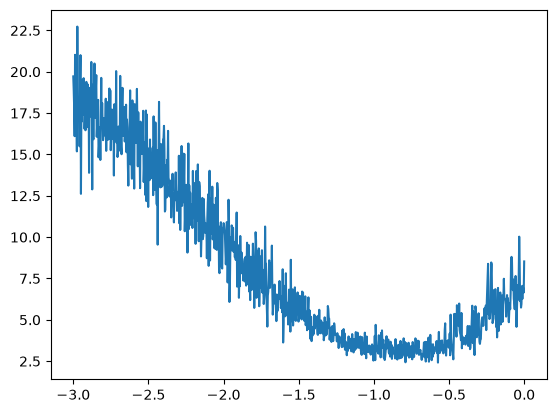

In [24]:
plt.plot(lri, lossi)

In [34]:
def build_data(words):
    X, Y = [], []
    block_size = 3
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return (X, Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_data(words[:n1])
Xdev, Ydev = build_data(words[n1:n2])
Xte, Yte = build_data(words[n2:])

torch.Size([182512, 3]) torch.Size([182512])
torch.Size([22860, 3]) torch.Size([22860])
torch.Size([22774, 3]) torch.Size([22774])


In [58]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn((200), generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [59]:
stepi = []
lossi = []
epoch = 30000
for i in range(epoch):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    stepi.append(i)
    lossi.append(loss.item())
    if i == 0 or i == epoch-1:
        print(f'{loss=}')

loss=tensor(28.3276, grad_fn=<NllLossBackward0>)
loss=tensor(2.2572, grad_fn=<NllLossBackward0>)


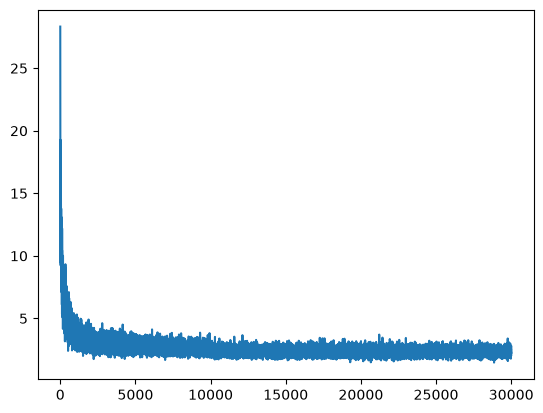

In [61]:
plt.plot(stepi, lossi)

In [54]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f'{loss=}')

loss=tensor(2.3314, grad_fn=<NllLossBackward0>)


In [60]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f'{loss=}')

loss=tensor(2.3259, grad_fn=<NllLossBackward0>)


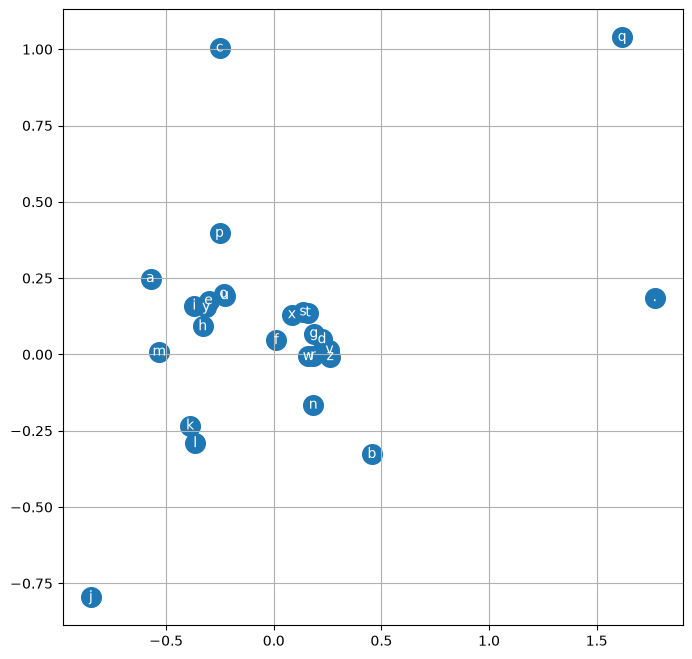

In [62]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [65]:
g = torch.Generator().manual_seed(2147483647)

block_size = 3

for i in range(30):
    out = []
    context = block_size * [0]
    while True:
        emb = C[torch.tensor(context)]
        h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))

dex.
maroallurailah.
tyha.
konimittainella.
kakanda.
samiyah.
javer.
gotai.
molie.
cavo.
kepteda.
kater.
maside.
enkaviyn.
ratlse.
hani.
ebrtahlah.
kasdr.
dan.
glayyaw.
isa.
jare.
din.
kez.
mycen.
dairit.
kaika.
bradisaa.
hakiys.
quten.
